In [2]:
import os

In [3]:
import tarfile

In [4]:
import urllib

In [5]:
download_root="https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH=os.path.join(os.getcwd(),"datasets","housing")
HOUSING_URL=download_root+"datasets/housing/housing.tgz"

def fetch_housing_data(housing_path=HOUSING_PATH,housing_url=HOUSING_URL):
    os.makedirs(housing_path,exist_ok=True)
    tgz_path=os.path.join(housing_path,"housing.tgz")
    urllib.request.urlretrieve(housing_url,tgz_path)
    housing_tgz=tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
fetch_housing_data()

In [6]:
print(os.getcwd())

C:\Users\sneha\Machine_learning_projects


In [7]:
print(HOUSING_PATH)

C:\Users\sneha\Machine_learning_projects\datasets\housing


In [8]:
print(os.path.abspath(HOUSING_PATH))

C:\Users\sneha\Machine_learning_projects\datasets\housing


In [9]:
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path=os.path.join(housing_path,"housing.csv")
    return pd.read_csv(csv_path)

In [10]:
housing=load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
print(os.path.exists(HOUSING_PATH))          # True/False
print(os.listdir(HOUSING_PATH))    

True
['housing.csv', 'housing.tgz']


In [12]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [13]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [14]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


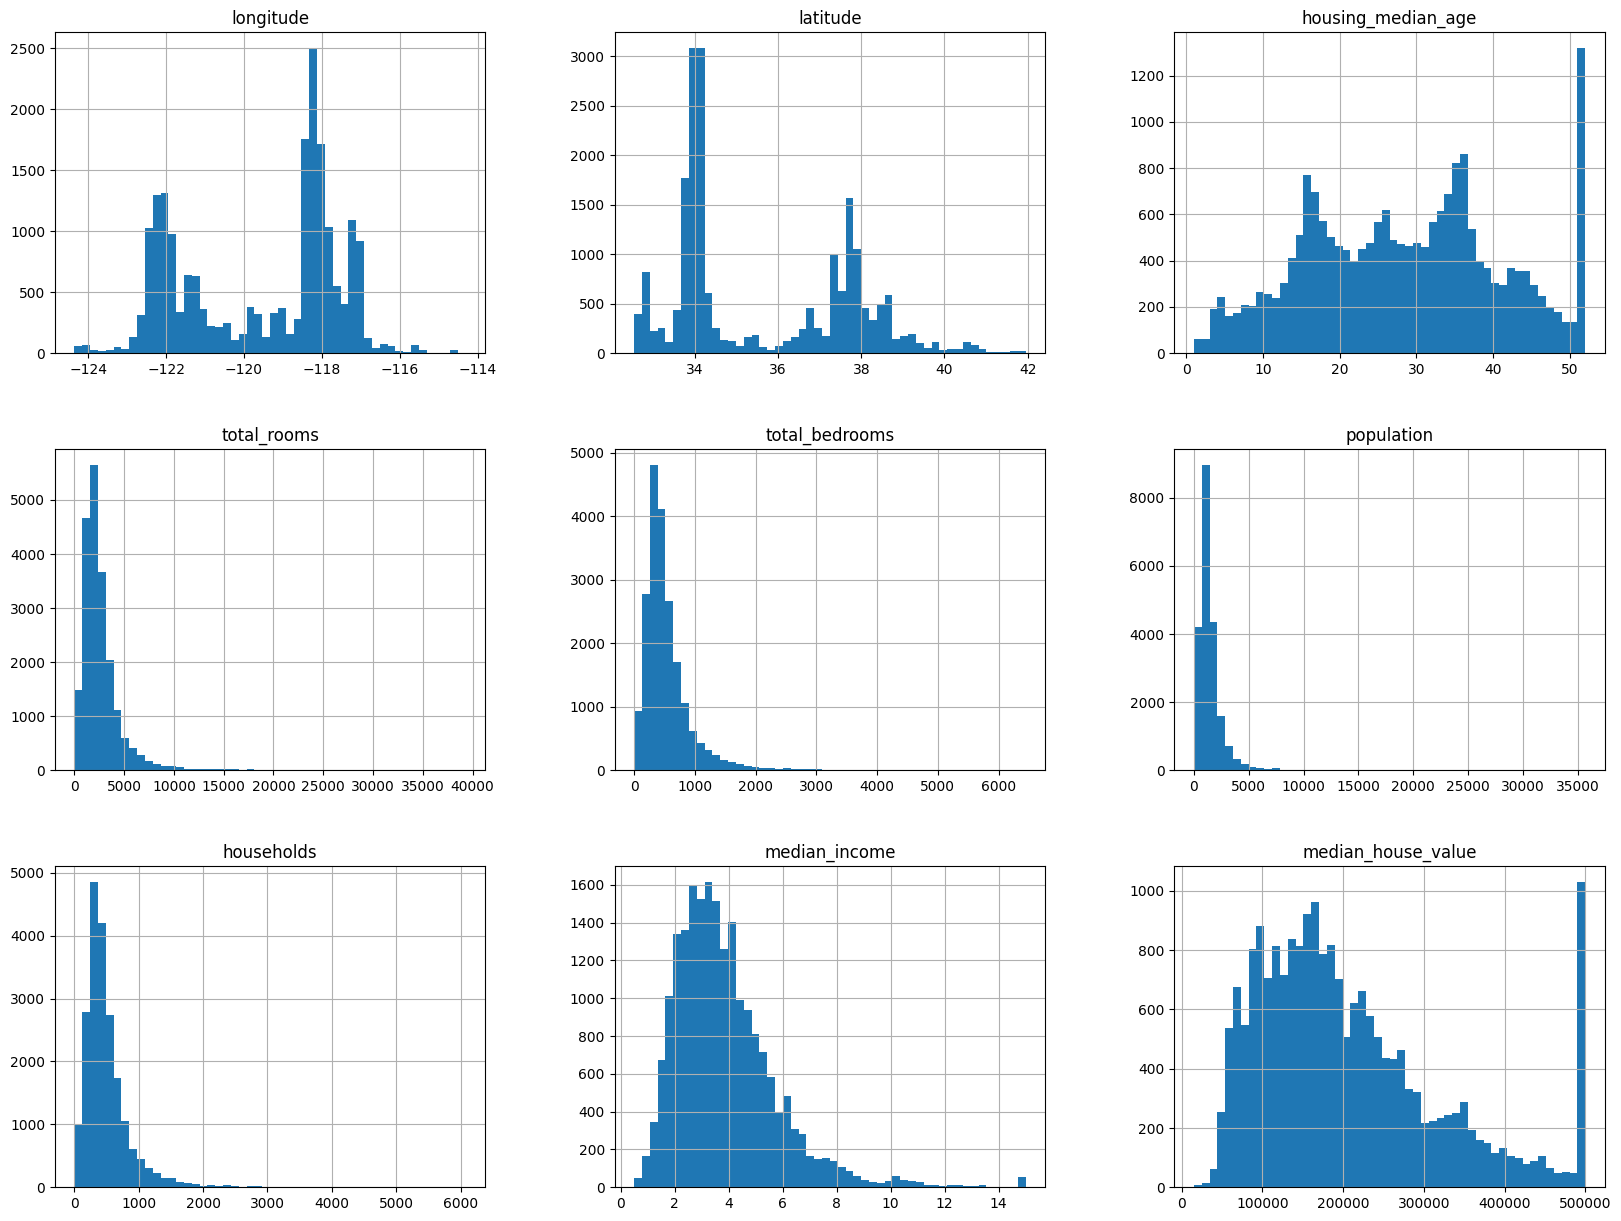

In [15]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [16]:
import numpy as np
def split_train_test(data,test_ratio):
    shuffled_indices=np.random.permutation(len(data))
    test_set_size=int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices],data.iloc[test_indices]
train_set,test_set=split_train_test(housing,0.2)                

In [17]:
len(train_set)

16512

In [18]:
len(test_set)

4128

In [19]:
# Well, this works, but it is not perfect: if you run the program again, it will generate a
# different test set! Over time, you (or your Machine Learning algorithms) will get to
# see the whole dataset, which is what you want to avoid.

# One solution is to save the test set on the first run and then load it in subsequent
# runs. Another option is to set the random number generator’s seed (e.g., with np.ran
# dom.seed(42))14 before calling np.random.permutation() so that it always generates
# the same shuffled indices.

# But both these solutions will break the next time you fetch an updated dataset. To
# have a stable train/test split even after updating the dataset, a common solution is to
# use each instance’s identifier to decide whether or not it should go in the test set
# (assuming instances have a unique and immutable identifier). For example, you could
# compute a hash of each instance’s identifier and put that instance in the test set if the
# hash is lower than or equal to 20% of the maximum hash value. This ensures that the
# test set will remain consistent across multiple runs, even if you refresh the dataset.
# The new test set will contain 20% of the new instances, but it will not contain any
# instance that was previously in the training set.

# Old data stayed where it was.
# Only the new data got added appropriately.

In [20]:
from zlib import crc32 #crc32 is hash function

In [21]:
def test_set_check(identifier,test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio*2**32

In [22]:
def split_train_test_by_id(data,test_ratio,id_column):
    ids=data[id_column]
    in_test_set=ids.apply(lambda id_:test_set_check(id_,test_ratio))
    #in in_test_set we have returned value of true and false from checker function
    # like for each data point having true and false labels
    # thus in below using .loc[] which got the labels ~ represent true for false values
    return data.loc[~in_test_set],data.loc[in_test_set]

In [23]:
housing_with_id=housing.reset_index() # adds an 'index' column
train_set,test_set=split_train_test_by_id(housing_with_id,0.2,"index")

In [24]:
# If you use the row index as a unique identifier, you need to make sure that new data
# gets appended to the end of the dataset and that no row ever gets deleted. If this is not
# possible, then you can try to use the most stable features to build a unique identifier.
# For example, a district’s latitude and longitude are guaranteed to be stable for a few
# million years, so you could combine them into an ID like so

In [25]:
housing_with_id["id"]=housing["longitude"] * 1000 + housing["latitude"]
train_set,test_set=split_train_test_by_id(housing_with_id,0.2,"id")

In [26]:
from sklearn.model_selection import train_test_split
train_test,test_set=train_test_split(housing,test_size=0.2,random_state=42)

In [27]:
train_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,INLAND


In [28]:
train_test,test_set=train_test_split(housing,test_size=0.2,random_state=42)

In [29]:
train_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,103000.0,NEAR OCEAN
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,382100.0,NEAR OCEAN
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,172600.0,NEAR OCEAN
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,93400.0,NEAR OCEAN
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,96500.0,INLAND


In [30]:
train_test2,test_set2=train_test_split(housing,test_size=0.2,random_state=40)

In [31]:
train_test2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9226,-120.04,36.93,11.0,3606.0,699.0,2074.0,644.0,2.6941,63300.0,INLAND
11826,-121.04,39.00,21.0,4059.0,730.0,1874.0,693.0,4.8051,174300.0,INLAND
4553,-118.24,34.06,33.0,390.0,199.0,435.0,193.0,1.1979,350000.0,<1H OCEAN
10787,-117.92,33.64,25.0,2224.0,580.0,985.0,516.0,3.1305,268800.0,<1H OCEAN
4104,-118.35,34.13,39.0,1610.0,278.0,511.0,278.0,4.3333,385900.0,<1H OCEAN


In [32]:
#there is a sampling bias where sampling can be skewed like in a 54%female and 47%male
# population if wants to sample out 100 people then a homogeneous amt of both 
#female and male would be considered.

In [33]:
import pandas as pd
housing["income_cat"]=pd.cut(housing["median_income"],bins=[0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])
#cut is used to convert like a continous values to categorical

<Axes: >

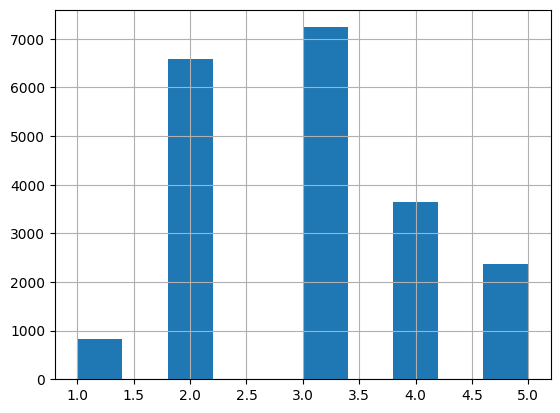

In [34]:
housing["income_cat"].hist()

In [35]:
from sklearn.model_selection import StratifiedShuffleSplit
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(housing,housing["income_cat"]):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]
strat_test_set["income_cat"].value_counts()


income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [36]:
train_test3,test_set3=train_test_split(housing,test_size=0.2,random_state=40)

In [37]:
test_set3["income_cat"].value_counts()

income_cat
3    1458
2    1294
4     710
5     494
1     172
Name: count, dtype: int64

In [38]:
for set_ in (strat_train_set,strat_test_set):
    set_.drop("income_cat",axis=1,inplace=True)

In [39]:
housing=strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

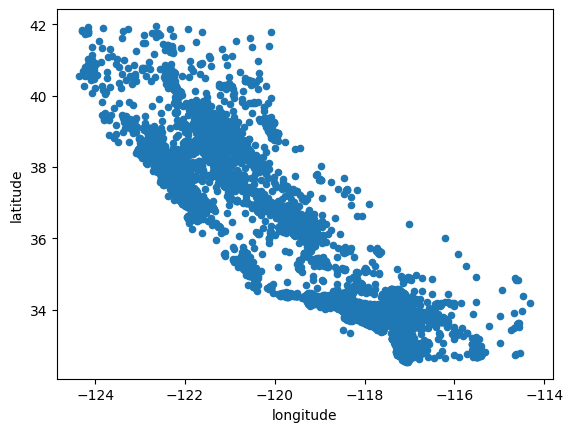

In [40]:
housing.plot(kind="scatter",x="longitude",y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

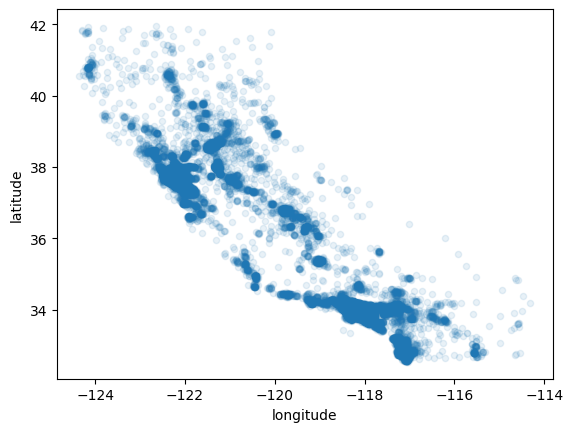

In [41]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.1)#alpha for transparency used to detect density areas

<Axes: xlabel='longitude', ylabel='latitude'>

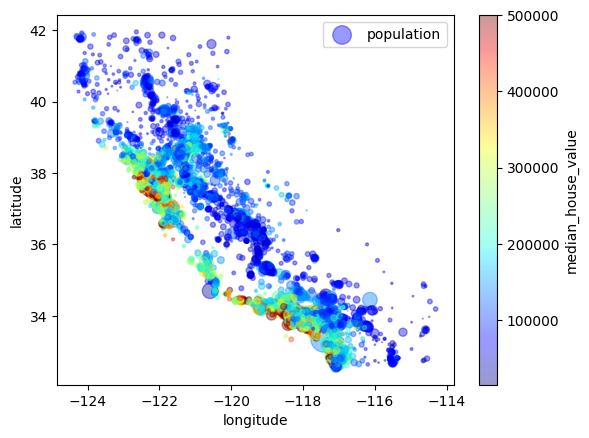

In [42]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
             s=housing["population"]/100,label="population",
             c="median_house_value",cmap=plt.get_cmap("jet"),colorbar=True
            )

In [43]:
#Correlation between attributes

In [44]:
corr_matrix=housing.drop("ocean_proximity",axis=1).corr()# as it was string valued

In [45]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

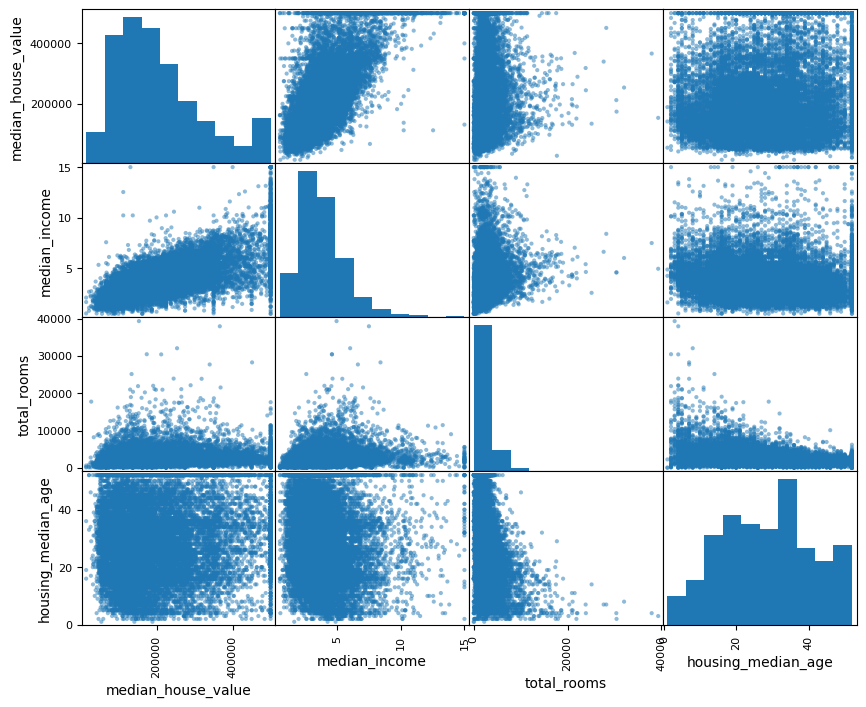

In [46]:
from pandas.plotting import scatter_matrix
attributes=["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(10,8))

In [47]:
# combining attributes

In [48]:
housing["rooms_per_household"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"]=housing["total_bedrooms"]/housing["total_rooms"]


In [49]:
# we can do data cleaning
# for first we can have the handling missing values
# some of the mthods: we can drop the attribute or may dropna that particular tuples or replace them with some val like mean/median
# we can use imputer from scikit learn
from sklearn.impute import SimpleImputer
inst_imputer=SimpleImputer(strategy="median")


In [50]:
housing=strat_train_set.drop("median_house_value",axis=1)

In [51]:
housing_labels=strat_train_set["median_house_value"]

In [52]:
housing_num=housing.drop("ocean_proximity",axis=1)

In [53]:
inst_imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [54]:
inst_imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [55]:
inst_imputer.transform(housing_num)

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [56]:
# categorical attributes handling
housing_cat=housing[["ocean_proximity"]]

In [58]:
X=inst_imputer.transform(housing_num)

In [59]:
housing_num.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [60]:
housing_num.index

Index([12655, 15502,  2908, 14053, 20496,  1481, 18125,  5830, 17989,  4861,
       ...
       12396, 16476,  2271,  6980,  5206, 15174, 12661, 19263, 19140, 19773],
      dtype='int64', length=16512)

In [62]:
#X isa numpy array but if i want dataframe then pd.DataFrame can be used
housing_tr=pd.DataFrame(X,columns=housing_num.columns,index=housing_num.index)

In [63]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_enc=OrdinalEncoder()

In [64]:
housing_cat_ord=ordinal_enc.fit_transform(housing_cat)
housing_cat_ord

array([[1.],
       [4.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]])

In [65]:
ordinal_enc.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [66]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder=OneHotEncoder()

In [67]:
housing_cate_one_hot=one_hot_encoder.fit_transform(housing_cat)

In [68]:
housing_cate_one_hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [69]:
housing_cate_one_hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])